# AI Link Prediction Models

In this notebook, I evaluate learned link prediction models on the same missing-edge reconstruction task used in the baseline notebook.

I use Node2Vec to learn node embeddings from the observed graph. These embeddings are then used as inputs to two different predictive models:

- a supervised multilayer perceptron (MLP)
- a reinforcement learning agent based on a Deep Q-Network (DQN)

Using the same held-out edge setup as the baseline notebook allows direct comparison between classical structural heuristics and learned models.

In [1]:
import random
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import urllib.request
import gzip
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import node2vec as n2v

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
def make_holdout_split(G, remove_fraction=0.10):
    """
    Remove a random fraction of true edges from the graph.

    Returns
    -------
    G_obs : networkx.Graph
        Observed graph after removing edges.
    removed_edges : list of tuple
        Removed edge list.
    true_removed : set of tuple
        Removed edges stored as sorted tuples for fast lookup.
    """
    G_obs = G.copy()

    edges = list(G_obs.edges())
    num_remove = int(len(edges) * remove_fraction)

    removed_edges = random.sample(edges, num_remove)
    G_obs.remove_edges_from(removed_edges)

    true_removed = set(tuple(sorted(edge)) for edge in removed_edges)

    return G_obs, removed_edges, true_removed


def train_node2vec_embeddings(
    G_obs,
    dimensions=64,
    walk_length=20,
    num_walks=100,
    workers=1,
    window=10,
    min_count=1,
    batch_words=128
):
    node2vec = n2v.Node2Vec(
        G_obs,
        dimensions=dimensions,
        walk_length=walk_length,
        num_walks=num_walks,
        workers=workers
    )

    model = node2vec.fit(
        window=window,
        min_count=min_count,
        batch_words=batch_words
    )

    return model


def edge_features(G, model, u, v):
    """
    Construct an edge-level feature vector from Node2Vec embeddings
    and basic degree information.

    Features:
    - Hadamard product of node embeddings
    - Absolute difference of node embeddings
    - Degree of u
    - Degree of v
    """
    emb_u = model.wv[str(u)]
    emb_v = model.wv[str(v)]

    hadamard = emb_u * emb_v
    abs_diff = np.abs(emb_u - emb_v)

    deg_u = G.degree(u)
    deg_v = G.degree(v)

    extra = np.array([deg_u, deg_v], dtype=np.float32)

    return np.concatenate([hadamard, abs_diff, extra]).astype(np.float32)


def build_candidate_edges(G_obs):
    """
    Build candidate non-edge set for prediction.

    Restrict to node pairs with at least one common neighbor
    to reduce the candidate space while preserving plausible links.
    """
    candidate_edges = []

    for u, v in nx.non_edges(G_obs):
        cn = len(list(nx.common_neighbors(G_obs, u, v)))
        if cn > 0:
            candidate_edges.append((u, v))

    return candidate_edges


def build_balanced_edge_dataset(G_obs, model, true_removed, candidate_edges):
    """
    Build a balanced supervised dataset for MLP training.

    Positive examples:
    - candidate edges that are truly removed edges

    Negative examples:
    - randomly sampled candidate edges that are not removed edges
    """
    positive_edges = [
        edge for edge in candidate_edges
        if tuple(sorted(edge)) in true_removed
    ]

    negative_edges_all = [
        edge for edge in candidate_edges
        if tuple(sorted(edge)) not in true_removed
    ]

    num_pos = len(positive_edges)
    negative_edges = random.sample(negative_edges_all, num_pos)

    X = []
    y = []

    for u, v in positive_edges:
        X.append(edge_features(G_obs, model, u, v))
        y.append(1)

    for u, v in negative_edges:
        X.append(edge_features(G_obs, model, u, v))
        y.append(0)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, positive_edges, negative_edges


def rank_candidate_edges_mlp(G_obs, model, mlp_model, candidate_edges, device):
    """
    Score and rank candidate edges using a trained MLP.
    """
    all_features = np.array(
        [edge_features(G_obs, model, u, v) for u, v in candidate_edges],
        dtype=np.float32
    )

    all_features_t = torch.tensor(all_features, dtype=torch.float32).to(device)

    mlp_model.eval()
    with torch.no_grad():
        all_logits = mlp_model(all_features_t)
        all_probs = torch.sigmoid(all_logits).cpu().numpy().flatten()

    scores = [
        (u, v, score)
        for (u, v), score in zip(candidate_edges, all_probs)
    ]

    scores = sorted(scores, key=lambda x: x[2], reverse=True)

    return scores


def recovery_rate_from_ranked_edges(ranked_edges, true_removed, k):
    """
    Compute recovery rate by taking the top-k ranked edges.
    """
    predicted_edges = [(u, v) for u, v, score in ranked_edges[:k]]
    predicted_set = set(tuple(sorted(edge)) for edge in predicted_edges)

    correct = true_removed.intersection(predicted_set)

    return len(correct) / len(true_removed), predicted_set, correct

In [3]:
def evaluate_mlp_link_prediction(
    G,
    dataset_name,
    remove_fraction=[0.05,0.10,0.15,0.20],
    n_trials=5
):

    results = []

    for frac in remove_fraction:

        for trial in range(1, n_trials+1):

            print(f"\n===== {dataset_name} ({int(frac*100)}% removed, trial {trial}) =====")

            G_obs, removed_edges, true_removed = make_holdout_split(G, frac)

            n2v_model = train_node2vec_embeddings(G_obs, workers=1)

            candidate_edges = build_candidate_edges(G_obs)

            X, y, pos, neg = build_balanced_edge_dataset(
                G_obs,
                n2v_model,
                true_removed,
                candidate_edges
            )

            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=0.3,
                random_state=42,
                stratify=y
            )

            model = EdgeMLP(X_train.shape[1]).to(device)
            optimizer = optim.Adam(model.parameters(), lr=1e-3)
            loss_fn = nn.BCEWithLogitsLoss()

            X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
            y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

            for epoch in range(20):

                model.train()

                logits = model(X_train_t)
                loss = loss_fn(logits, y_train_t)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            recovery = compute_mlp_recovery_rate(
                G_obs,
                removed_edges,
                candidate_edges,
                model,
                n2v_model
            )

            print("MLP recovery rate:", recovery)

            results.append({
                "dataset": dataset_name,
                "remove_fraction": frac,
                "trial": trial,
                "recovery_mlp": recovery
            })

    return pd.DataFrame(results)

In [8]:
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
urllib.request.urlretrieve(url, "facebook_combined.txt.gz")

with gzip.open("facebook_combined.txt.gz", "rb") as f_in:
    with open("facebook_edges.txt", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

edges_facebook = pd.read_csv(
    "facebook_edges.txt",
    sep=" ",
    header=None,
    names=["u", "v"]
)

G_facebook = nx.from_pandas_edgelist(edges_facebook, source="u", target="v")

print("Facebook nodes:", G_facebook.number_of_nodes())
print("Facebook edges:", G_facebook.number_of_edges())

Facebook nodes: 4039
Facebook edges: 88234


In [17]:
from sklearn.model_selection import train_test_split

X_train_fb, X_test_fb, y_train_fb, y_test_fb = train_test_split(
    X_fb,
    y_fb,
    test_size=0.30,
    random_state=42,
    stratify=y_fb
)

print("Train size:", X_train_fb.shape)
print("Test size:", X_test_fb.shape)

Train size: (12310, 130)
Test size: (5276, 130)


In [18]:
class EdgeMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


mlp_fb = EdgeMLP(X_train_fb.shape[1]).to(device)
optimizer_fb = optim.Adam(mlp_fb.parameters(), lr=1e-3)
loss_fn_fb = nn.BCEWithLogitsLoss()

print(mlp_fb)

EdgeMLP(
  (net): Sequential(
    (0): Linear(in_features=130, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [22]:
def compute_mlp_recovery_rate(
    G_obs,
    removed_edges,
    candidate_edges,
    model,
    node2vec_model
):

    model.eval()

    features = []

    for u, v in candidate_edges:

        emb_u = node2vec_model.wv[str(u)]
        emb_v = node2vec_model.wv[str(v)]

        cn = len(list(nx.common_neighbors(G_obs, u, v)))
        deg_u = G_obs.degree(u)
        deg_v = G_obs.degree(v)

        feat = np.concatenate([
            emb_u,
            emb_v,
            [cn, deg_u + deg_v]
        ])

        features.append(feat)

    X = torch.tensor(np.array(features), dtype=torch.float32).to(device)

    with torch.no_grad():
        probs = torch.sigmoid(model(X)).cpu().numpy().flatten()

    scored_edges = list(zip(candidate_edges, probs))
    scored_edges.sort(key=lambda x: x[1], reverse=True)

    k = len(removed_edges)

    predicted_edges = set(
        tuple(sorted(edge))
        for edge, _ in scored_edges[:k]
    )

    true_removed = set(tuple(sorted(e)) for e in removed_edges)

    correct = predicted_edges.intersection(true_removed)

    recovery_rate = len(correct) / len(true_removed)

    return recovery_rate

In [27]:
facebook_mlp_trials = evaluate_mlp_link_prediction(
    G_facebook,
    "Facebook Social Circles",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=1
)


===== Facebook Social Circles (5% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [01:35<00:00,  1.05it/s]


MLP recovery rate: 0.24484243935615507

===== Facebook Social Circles (10% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


MLP recovery rate: 0.16524367208160182

===== Facebook Social Circles (20% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [01:25<00:00,  1.17it/s]


MLP recovery rate: 0.24889493369602175


In [12]:
url = "https://snap.stanford.edu/data/ca-GrQc.txt.gz"
urllib.request.urlretrieve(url, "ca-GrQc.txt.gz")

with gzip.open("ca-GrQc.txt.gz", "rb") as f_in:
    with open("arxiv_edges.txt", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

edges_arxiv = pd.read_csv(
    "arxiv_edges.txt",
    sep="\t",
    comment="#",
    header=None,
    names=["u", "v"]
)

G_arxiv = nx.from_pandas_edgelist(edges_arxiv, source="u", target="v")

print("ArXiv nodes:", G_arxiv.number_of_nodes())
print("ArXiv edges:", G_arxiv.number_of_edges())

ArXiv nodes: 5242
ArXiv edges: 14496


In [29]:
arxiv_mlp_trials = evaluate_mlp_link_prediction(
    G_arxiv,
    "ArXiv GR-QC Collaboration Network",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=1
)


===== ArXiv GR-QC Collaboration Network (5% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/5242 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:42<00:00,  2.36it/s]


MLP recovery rate: 0.2983425414364641

===== ArXiv GR-QC Collaboration Network (10% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/5242 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:39<00:00,  2.54it/s]


MLP recovery rate: 0.32842686292548295

===== ArXiv GR-QC Collaboration Network (20% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/5242 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:38<00:00,  2.58it/s]


MLP recovery rate: 0.32942393928941016


In [13]:
url = "https://snap.stanford.edu/data/email-Eu-core.txt.gz"
urllib.request.urlretrieve(url, "email-Eu-core.txt.gz")

with gzip.open("email-Eu-core.txt.gz", "rb") as f_in:
    with open("email_edges.txt", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

edges_email = pd.read_csv(
    "email_edges.txt",
    sep=" ",
    header=None,
    names=["u", "v"]
)

G_email = nx.from_pandas_edgelist(edges_email, source="u", target="v")

print("Email nodes:", G_email.number_of_nodes())
print("Email edges:", G_email.number_of_edges())

Email nodes: 1005
Email edges: 16706


In [31]:
email_mlp_trials = evaluate_mlp_link_prediction(
    G_email,
    "Email Communication Network",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=1
)


===== Email Communication Network (5% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/1005 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:20<00:00,  4.83it/s]


MLP recovery rate: 0.09700598802395209

===== Email Communication Network (10% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/1005 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:19<00:00,  5.12it/s]


MLP recovery rate: 0.15568862275449102

===== Email Communication Network (20% removed, trial 1) =====


Computing transition probabilities:   0%|          | 0/1005 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [00:18<00:00,  5.51it/s]


MLP recovery rate: 0.21819814426818318


In [32]:
mlp_trials = pd.concat(
    [facebook_mlp_trials, arxiv_mlp_trials, email_mlp_trials],
    ignore_index=True
)

mlp_trials["remove_percent"] = mlp_trials["remove_fraction"] * 100

mlp_trials

,dataset,remove_fraction,trial,recovery_mlp,remove_percent
0,Facebook Social Circles,0.05,1,0.244842,5.0
1,Facebook Social Circles,0.10,1,0.346707,10.0
2,Facebook Social Circles,0.15,1,0.165244,15.0
3,Facebook Social Circles,0.20,1,0.248895,20.0
4,ArXiv GR-QC Collaboration Network,0.05,1,0.298343,5.0
5,ArXiv GR-QC Collaboration Network,0.10,1,0.306418,10.0
6,ArXiv GR-QC Collaboration Network,0.15,1,0.328427,15.0
7,ArXiv GR-QC Collaboration Network,0.20,1,0.329424,20.0
8,Email Communication Network,0.05,1,0.097006,5.0
9,Email Communication Network,0.10,1,0.206587,10.0


In [37]:
summary_table = pd.read_csv("baseline_summary_table.csv")
summary_table

,dataset,remove_fraction,cn_mean,cn_std,aa_mean,aa_std,jc_mean,jc_std,remove_percent
0,ArXiv GR-QC Collaboration Network,0.05,0.319890,0.020030,0.431768,0.021097,0.297790,0.014004,5.0
1,ArXiv GR-QC Collaboration Network,0.10,0.351001,0.008792,0.480883,0.005762,0.346998,0.005332,10.0
2,ArXiv GR-QC Collaboration Network,0.15,0.376357,0.009345,0.517847,0.010526,0.341306,0.010020,15.0
3,ArXiv GR-QC Collaboration Network,0.20,0.411659,0.014104,0.536668,0.009508,0.401794,0.008212,20.0
4,Email Communication Network,0.05,0.137485,0.009670,0.152335,0.008735,0.138443,0.004835,5.0
5,Email Communication Network,0.10,0.196407,0.008123,0.219760,0.009002,0.205030,0.002631,10.0
6,Email Communication Network,0.15,0.237844,0.005498,0.264511,0.003347,0.234012,0.008026,15.0
7,Email Communication Network,0.20,0.259623,0.009870,0.290153,0.011473,0.264831,0.005859,20.0
8,Facebook Social Circles,0.05,0.236046,0.004740,0.250011,0.004611,0.229971,0.003184,5.0
9,Facebook Social Circles,0.10,0.312524,0.004154,0.327666,0.003985,0.322589,0.002843,10.0


In [38]:
baseline_compare = summary_table.copy()

mlp_compare = mlp_trials[["dataset", "remove_fraction", "recovery_mlp"]].copy()

comparison_table = baseline_compare.merge(
    mlp_compare,
    on=["dataset", "remove_fraction"],
    how="left"
)

comparison_table

,dataset,remove_fraction,cn_mean,cn_std,aa_mean,aa_std,jc_mean,jc_std,remove_percent,recovery_mlp
0,ArXiv GR-QC Collaboration Network,0.05,0.319890,0.020030,0.431768,0.021097,0.297790,0.014004,5.0,0.298343
1,ArXiv GR-QC Collaboration Network,0.10,0.351001,0.008792,0.480883,0.005762,0.346998,0.005332,10.0,0.306418
2,ArXiv GR-QC Collaboration Network,0.15,0.376357,0.009345,0.517847,0.010526,0.341306,0.010020,15.0,0.328427
3,ArXiv GR-QC Collaboration Network,0.20,0.411659,0.014104,0.536668,0.009508,0.401794,0.008212,20.0,0.329424
4,Email Communication Network,0.05,0.137485,0.009670,0.152335,0.008735,0.138443,0.004835,5.0,0.097006
5,Email Communication Network,0.10,0.196407,0.008123,0.219760,0.009002,0.205030,0.002631,10.0,0.206587
6,Email Communication Network,0.15,0.237844,0.005498,0.264511,0.003347,0.234012,0.008026,15.0,0.155689
7,Email Communication Network,0.20,0.259623,0.009870,0.290153,0.011473,0.264831,0.005859,20.0,0.218198
8,Facebook Social Circles,0.05,0.236046,0.004740,0.250011,0.004611,0.229971,0.003184,5.0,0.244842
9,Facebook Social Circles,0.10,0.312524,0.004154,0.327666,0.003985,0.322589,0.002843,10.0,0.346707


In [20]:
# Hard coded for future use after runtime goes down (see above for original)

import pandas as pd

comparison_table = pd.DataFrame({
    "dataset": [
        "ArXiv GR-QC Collaboration Network",
        "ArXiv GR-QC Collaboration Network",
        "ArXiv GR-QC Collaboration Network",
        "ArXiv GR-QC Collaboration Network",
        "Email Communication Network",
        "Email Communication Network",
        "Email Communication Network",
        "Email Communication Network",
        "Facebook Social Circles",
        "Facebook Social Circles",
        "Facebook Social Circles",
        "Facebook Social Circles",
    ],
    "remove_fraction": [0.05, 0.10, 0.15, 0.20,
                        0.05, 0.10, 0.15, 0.20,
                        0.05, 0.10, 0.15, 0.20],
    "cn_mean": [0.319890, 0.351001, 0.376357, 0.411659,
                0.137485, 0.196407, 0.237844, 0.259623,
                0.236046, 0.312524, 0.356101, 0.394684],
    "cn_std": [0.020030, 0.008792, 0.009345, 0.014104,
               0.009670, 0.008123, 0.005498, 0.009870,
               0.004740, 0.004154, 0.003460, 0.005329],
    "aa_mean": [0.431768, 0.480883, 0.517847, 0.536668,
                0.152335, 0.219760, 0.264511, 0.290153,
                0.250011, 0.327666, 0.376759, 0.418418],
    "aa_std": [0.021097, 0.005762, 0.010526, 0.009508,
               0.008735, 0.009002, 0.003347, 0.011473,
               0.004611, 0.003985, 0.002956, 0.004421],
    "jc_mean": [0.297790, 0.346998, 0.341306, 0.401794,
                0.138443, 0.205030, 0.234012, 0.264831,
                0.229971, 0.322589, 0.389588, 0.404772],
    "jc_std": [0.014004, 0.005332, 0.010020, 0.008212,
               0.004835, 0.002631, 0.008026, 0.005859,
               0.003184, 0.002843, 0.003984, 0.006967],
    "remove_percent": [5.0, 10.0, 15.0, 20.0,
                       5.0, 10.0, 15.0, 20.0,
                       5.0, 10.0, 15.0, 20.0],
    "recovery_mlp": [0.298343, 0.306418, 0.328427, 0.329424,
                     0.097006, 0.206587, 0.155689, 0.218198,
                     0.244842, 0.346707, 0.165244, 0.248895]
})

comparison_table

,dataset,remove_fraction,cn_mean,cn_std,aa_mean,aa_std,jc_mean,jc_std,remove_percent,recovery_mlp
0,ArXiv GR-QC Collaboration Network,0.05,0.319890,0.020030,0.431768,0.021097,0.297790,0.014004,5.0,0.298343
1,ArXiv GR-QC Collaboration Network,0.10,0.351001,0.008792,0.480883,0.005762,0.346998,0.005332,10.0,0.306418
2,ArXiv GR-QC Collaboration Network,0.15,0.376357,0.009345,0.517847,0.010526,0.341306,0.010020,15.0,0.328427
3,ArXiv GR-QC Collaboration Network,0.20,0.411659,0.014104,0.536668,0.009508,0.401794,0.008212,20.0,0.329424
4,Email Communication Network,0.05,0.137485,0.009670,0.152335,0.008735,0.138443,0.004835,5.0,0.097006
5,Email Communication Network,0.10,0.196407,0.008123,0.219760,0.009002,0.205030,0.002631,10.0,0.206587
6,Email Communication Network,0.15,0.237844,0.005498,0.264511,0.003347,0.234012,0.008026,15.0,0.155689
7,Email Communication Network,0.20,0.259623,0.009870,0.290153,0.011473,0.264831,0.005859,20.0,0.218198
8,Facebook Social Circles,0.05,0.236046,0.004740,0.250011,0.004611,0.229971,0.003184,5.0,0.244842
9,Facebook Social Circles,0.10,0.312524,0.004154,0.327666,0.003985,0.322589,0.002843,10.0,0.346707


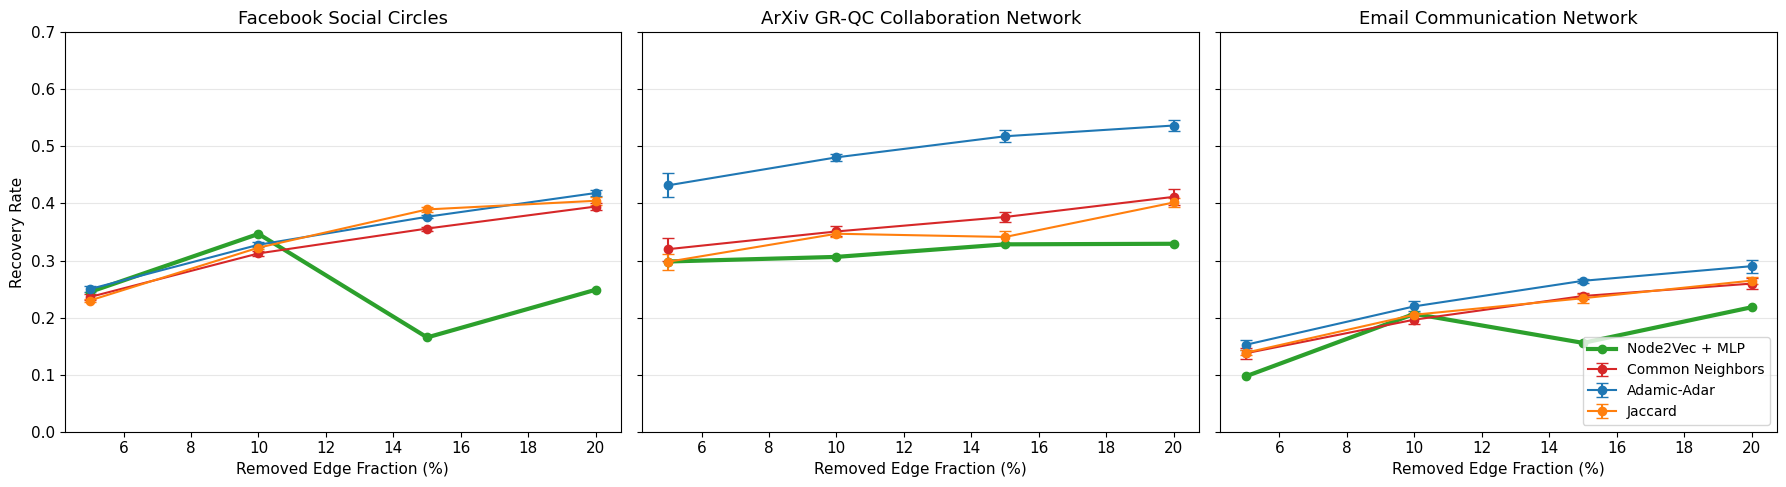

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

dataset_names = [
    "Facebook Social Circles",
    "ArXiv GR-QC Collaboration Network",
    "Email Communication Network"
]

for ax, dataset_name in zip(axes, dataset_names):

    df = comparison_table[comparison_table["dataset"] == dataset_name].copy()
    df = df.sort_values("remove_fraction")

    ax.errorbar(df["remove_percent"], df["cn_mean"], yerr=df["cn_std"],
                marker="o", color="#d62728", capsize=4, label="Common Neighbors")

    ax.errorbar(df["remove_percent"], df["aa_mean"], yerr=df["aa_std"],
                marker="o", color="#1f77b4", capsize=4, label="Adamic-Adar")

    ax.errorbar(df["remove_percent"], df["jc_mean"], yerr=df["jc_std"],
                marker="o", color="#ff7f0e", capsize=4, label="Jaccard")

    ax.plot(df["remove_percent"], df["recovery_mlp"],
            marker="o", linewidth=3, color="#2ca02c", label="Node2Vec + MLP")

    ax.set_title(dataset_name, fontsize=13)
    ax.set_xlabel("Removed Edge Fraction (%)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Recovery Rate", fontsize=11)
axes[0].set_ylim(0, 0.7)

axes[2].legend(loc="lower right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

Across the three networks, classical heuristics remain competitive with embedding-based methods. Adamic–Adar consistently achieves the highest recovery rates, particularly in the ArXiv collaboration network where strong triadic closure dominates link formation. The Node2Vec + MLP model performs comparably to the best heuristic in the Facebook and Email networks but does not significantly outperform Adamic–Adar. These results suggest that simple structural heuristics remain powerful baselines for link prediction, especially in networks where local clustering strongly drives edge formation.

# DQN Next

In [4]:
from collections import deque

class QNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)


def choose_action(q_net, state, epsilon, device):
    if random.random() < epsilon:
        return random.choice([0, 1])
    state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = q_net(state_t)
    return int(torch.argmax(q_values).item())


def reward_function(edge, true_removed, action):
    edge_sorted = tuple(sorted(edge))

    if action == 1 and edge_sorted in true_removed:
        return 1.0
    elif action == 1 and edge_sorted not in true_removed:
        return -1.0
    else:
        return 0.0


def optimize_dqn(q_net, optimizer, loss_fn, replay_buffer, batch_size, device):
    if len(replay_buffer) < batch_size:
        return None

    batch = random.sample(replay_buffer, batch_size)
    states, actions, rewards = zip(*batch)

    states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
    actions = torch.tensor(actions, dtype=torch.long).to(device)
    rewards = torch.tensor(rewards, dtype=torch.float32).to(device)

    q_values = q_net(states)
    q_selected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

    loss = loss_fn(q_selected, rewards)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


def rank_candidate_edges_dqn(G_obs, model, q_net, candidate_edges, device):
    q_net.eval()
    scores = []

    with torch.no_grad():
        for u, v in candidate_edges:
            state = edge_features(G_obs, model, u, v)
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = q_net(state_t).cpu().numpy()[0]
            score_add = q_values[1]
            scores.append((u, v, score_add))

    scores = sorted(scores, key=lambda x: x[2], reverse=True)
    return scores

In [5]:
def build_candidate_edges(G, mode="plausible_subset", top_k=20000):
    """
    Build candidate non-edges for link prediction.

    Parameters
    ----------
    G : networkx.Graph
        Observed graph.
    mode : str
        "plausible_subset" -> keep only top_k candidates ranked by common neighbors
        "all_cn_positive"  -> keep all non-edges with CN > 0
    top_k : int
        Number of candidates to keep if mode == "plausible_subset"

    Returns
    -------
    list of tuple
        Candidate edges as [(u, v), ...]
    """
    candidates = []

    for u, v in nx.non_edges(G):
        cn = len(list(nx.common_neighbors(G, u, v)))
        if cn > 0:
            candidates.append((u, v, cn))

    if mode == "all_cn_positive":
        return [(u, v) for u, v, cn in candidates]

    elif mode == "plausible_subset":
        candidates = sorted(candidates, key=lambda x: x[2], reverse=True)[:top_k]
        return [(u, v) for u, v, cn in candidates]

    else:
        raise ValueError("mode must be 'plausible_subset' or 'all_cn_positive'")

In [6]:
def evaluate_dqn_link_prediction(
    G,
    dataset_name,
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=1,
    episodes=3000,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    batch_size=64,
    candidate_mode="plausible_subset",
    top_k_candidates=20000
):
    rows = []

    for frac in remove_fraction:
        for trial in range(1, n_trials + 1):

            print(f"\n===== {dataset_name} ({int(frac*100)}% removed, trial {trial}) =====")

            G_obs, removed_edges, true_removed = make_holdout_split(G, frac)

            print("Original edges:", G.number_of_edges())
            print("Observed edges:", G_obs.number_of_edges())
            print("Removed edges:", len(removed_edges))

            n2v_model = train_node2vec_embeddings(
                G_obs,
                dimensions=64,
                walk_length=20,
                num_walks=40,
                workers=1,
                window=10,
                min_count=1,
                batch_words=128
            )

            candidate_edges = build_candidate_edges(
                G_obs,
                mode=candidate_mode,
                top_k=top_k_candidates
            )
            print("Candidate edges:", len(candidate_edges))

            sample_state = edge_features(
                G_obs,
                n2v_model,
                candidate_edges[0][0],
                candidate_edges[0][1]
            )
            state_dim = len(sample_state)

            q_net = QNetwork(state_dim).to(device)
            optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
            loss_fn = nn.MSELoss()
            replay_buffer = deque(maxlen=20000)

            epsilon = epsilon_start

            for episode in range(episodes):
                u, v = random.choice(candidate_edges)
                state = edge_features(G_obs, n2v_model, u, v)

                action = choose_action(q_net, state, epsilon, device)
                reward = reward_function((u, v), true_removed, action)

                replay_buffer.append((state, action, reward))
                _ = optimize_dqn(q_net, optimizer, loss_fn, replay_buffer, batch_size, device)

                epsilon = max(epsilon_min, epsilon * epsilon_decay)

            ranked_edges = rank_candidate_edges_dqn(
                G_obs,
                n2v_model,
                q_net,
                candidate_edges,
                device
            )

            k = len(removed_edges)
            recovery_dqn, _, _ = recovery_rate_from_ranked_edges(
                ranked_edges,
                true_removed,
                k
            )

            print("DQN recovery rate:", recovery_dqn)

            rows.append({
                "dataset": dataset_name,
                "remove_fraction": frac,
                "trial": trial,
                "candidate_mode": candidate_mode,
                "top_k_candidates": top_k_candidates,
                "recovery_dqn": recovery_dqn
            })

    return pd.DataFrame(rows)

In [14]:
facebook_dqn_focus = evaluate_dqn_link_prediction(
    G_facebook,
    "Facebook Social Circles",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=1,
    episodes=3000,
    candidate_mode="plausible_subset",
    top_k_candidates=20000
)


===== Facebook Social Circles (5% removed, trial 1) =====
Original edges: 88234
Observed edges: 83823
Removed edges: 4411


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:36<00:00,  1.09it/s]


Candidate edges: 20000
DQN recovery rate: 0.2706869190659714

===== Facebook Social Circles (10% removed, trial 1) =====
Original edges: 88234
Observed edges: 79411
Removed edges: 8823


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:33<00:00,  1.18it/s]


Candidate edges: 20000
DQN recovery rate: 0.3751416698148848

===== Facebook Social Circles (20% removed, trial 1) =====
Original edges: 88234
Observed edges: 70588
Removed edges: 17646


Computing transition probabilities:   0%|          | 0/4039 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:32<00:00,  1.24it/s]


Candidate edges: 20000
DQN recovery rate: 0.3995239714382863


In [16]:
arxiv_dqn_focus = evaluate_dqn_link_prediction(
    G_arxiv,
    "ArXiv GR-QC Collaboration Network",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=1,
    episodes=3000,
    candidate_mode="plausible_subset",
    top_k_candidates=20000
)


===== ArXiv GR-QC Collaboration Network (5% removed, trial 1) =====
Original edges: 14496
Observed edges: 13772
Removed edges: 724


Computing transition probabilities:   0%|          | 0/5242 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:17<00:00,  2.34it/s]


Candidate edges: 20000
DQN recovery rate: 0.2845303867403315

===== ArXiv GR-QC Collaboration Network (10% removed, trial 1) =====
Original edges: 14496
Observed edges: 13047
Removed edges: 1449


Computing transition probabilities:   0%|          | 0/5242 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:15<00:00,  2.55it/s]


Candidate edges: 20000
DQN recovery rate: 0.3702851885924563

===== ArXiv GR-QC Collaboration Network (20% removed, trial 1) =====
Original edges: 14496
Observed edges: 11597
Removed edges: 2899


Computing transition probabilities:   0%|          | 0/5242 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:15<00:00,  2.62it/s]


Candidate edges: 20000
DQN recovery rate: 0.37288720248361507


In [17]:
email_dqn_focus = evaluate_dqn_link_prediction(
    G_email,
    "Email Communication Network",
    remove_fraction=[0.05, 0.10, 0.15, 0.20],
    n_trials=1,
    episodes=3000,
    candidate_mode="plausible_subset",
    top_k_candidates=20000
)


===== Email Communication Network (5% removed, trial 1) =====
Original edges: 16706
Observed edges: 15871
Removed edges: 835


Computing transition probabilities:   0%|          | 0/1005 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:07<00:00,  5.07it/s]


Candidate edges: 20000
DQN recovery rate: 0.08862275449101796

===== Email Communication Network (10% removed, trial 1) =====
Original edges: 16706
Observed edges: 15036
Removed edges: 1670


Computing transition probabilities:   0%|          | 0/1005 [00:00<?, ?it/s]

...

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:07<00:00,  5.56it/s]


Candidate edges: 20000
DQN recovery rate: 0.14451097804391216

===== Email Communication Network (20% removed, trial 1) =====
Original edges: 16706
Observed edges: 13365
Removed edges: 3341


Computing transition probabilities:   0%|          | 0/1005 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 40/40 [00:06<00:00,  5.79it/s]


Candidate edges: 20000
DQN recovery rate: 0.2328644118527387


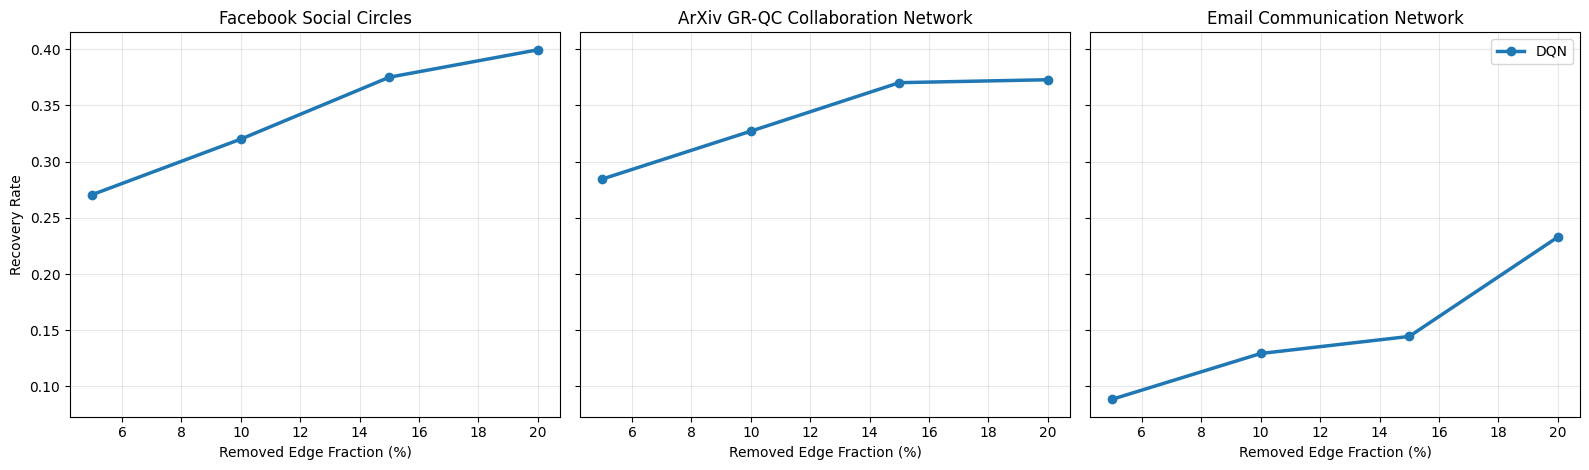

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

dataset_names = [
    "Facebook Social Circles",
    "ArXiv GR-QC Collaboration Network",
    "Email Communication Network"
]

for ax, dataset_name in zip(axes, dataset_names):
    df = comparison_table[comparison_table["dataset"] == dataset_name].copy()
    df = df.sort_values("remove_percent")

    ax.plot(
        df["remove_percent"],
        df["recovery_dqn"],
        marker="o",
        linewidth=2.5,
        label="DQN"
    )

    ax.set_title(dataset_name)
    ax.set_xlabel("Removed Edge Fraction (%)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Recovery Rate")
axes[2].legend()
plt.tight_layout()
plt.show()

In [21]:
dqn_trials = pd.concat(
    [facebook_dqn_focus, arxiv_dqn_focus, email_dqn_focus],
    ignore_index=True
)

dqn_compare = dqn_trials[["dataset", "remove_fraction", "recovery_dqn"]].copy()

comparison_table = comparison_table.merge(
    dqn_compare,
    on=["dataset", "remove_fraction"],
    how="left"
)

comparison_table = comparison_table.sort_values(
    ["dataset", "remove_fraction"]
).reset_index(drop=True)

comparison_table

,dataset,remove_fraction,cn_mean,cn_std,aa_mean,aa_std,jc_mean,jc_std,remove_percent,recovery_mlp,recovery_dqn
0,ArXiv GR-QC Collaboration Network,0.05,0.319890,0.020030,0.431768,0.021097,0.297790,0.014004,5.0,0.298343,0.284530
1,ArXiv GR-QC Collaboration Network,0.10,0.351001,0.008792,0.480883,0.005762,0.346998,0.005332,10.0,0.306418,0.327122
2,ArXiv GR-QC Collaboration Network,0.15,0.376357,0.009345,0.517847,0.010526,0.341306,0.010020,15.0,0.328427,0.370285
3,ArXiv GR-QC Collaboration Network,0.20,0.411659,0.014104,0.536668,0.009508,0.401794,0.008212,20.0,0.329424,0.372887
4,Email Communication Network,0.05,0.137485,0.009670,0.152335,0.008735,0.138443,0.004835,5.0,0.097006,0.088623
5,Email Communication Network,0.10,0.196407,0.008123,0.219760,0.009002,0.205030,0.002631,10.0,0.206587,0.129341
6,Email Communication Network,0.15,0.237844,0.005498,0.264511,0.003347,0.234012,0.008026,15.0,0.155689,0.144511
7,Email Communication Network,0.20,0.259623,0.009870,0.290153,0.011473,0.264831,0.005859,20.0,0.218198,0.232864
8,Facebook Social Circles,0.05,0.236046,0.004740,0.250011,0.004611,0.229971,0.003184,5.0,0.244842,0.270687
9,Facebook Social Circles,0.10,0.312524,0.004154,0.327666,0.003985,0.322589,0.002843,10.0,0.346707,0.320073


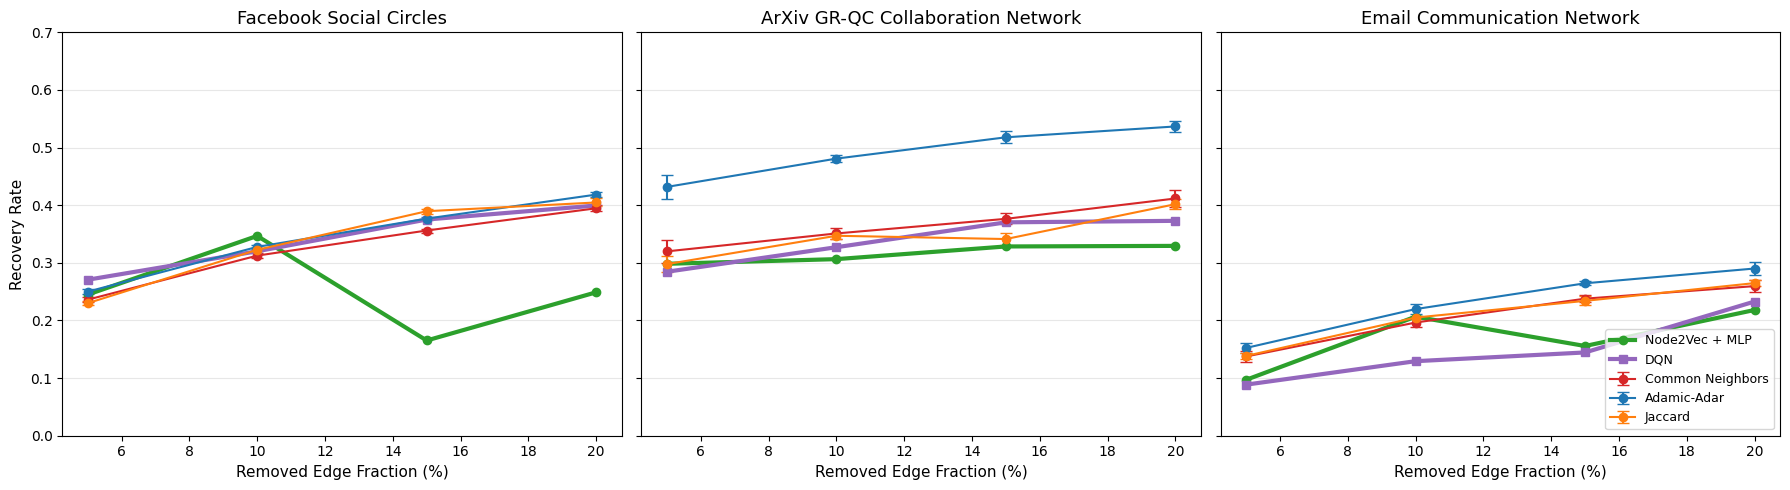

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

dataset_names = [
    "Facebook Social Circles",
    "ArXiv GR-QC Collaboration Network",
    "Email Communication Network"
]

for ax, dataset_name in zip(axes, dataset_names):

    df = comparison_table[comparison_table["dataset"] == dataset_name].copy()
    df = df.sort_values("remove_fraction")

    ax.errorbar(df["remove_percent"], df["cn_mean"], yerr=df["cn_std"],
                marker="o", color="#d62728", capsize=4, label="Common Neighbors")

    ax.errorbar(df["remove_percent"], df["aa_mean"], yerr=df["aa_std"],
                marker="o", color="#1f77b4", capsize=4, label="Adamic-Adar")

    ax.errorbar(df["remove_percent"], df["jc_mean"], yerr=df["jc_std"],
                marker="o", color="#ff7f0e", capsize=4, label="Jaccard")

    ax.plot(df["remove_percent"], df["recovery_mlp"],
            marker="o", linewidth=3, color="#2ca02c", label="Node2Vec + MLP")

    ax.plot(df["remove_percent"], df["recovery_dqn"],
            marker="s", linewidth=3, color="#9467bd", label="DQN")

    ax.set_title(dataset_name, fontsize=13)
    ax.set_xlabel("Removed Edge Fraction (%)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Recovery Rate", fontsize=11)
axes[0].set_ylim(0, 0.7)
axes[2].legend(loc="lower right", fontsize=9, frameon=True)

plt.tight_layout()
plt.show()